<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA

### Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

# 1. Imports y configuración

In [1]:
import re

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.utils import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten, LSTM, SimpleRNN
from keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Input

/Users/amaglione/Documents/Trabajos/ceia-uba/Bimestre 4 - PNL/PNL_Entrega_TPs/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 2. Cargo el dataset

In [2]:
# Descargar la carpeta de dataset
import os
import gdown

if os.access('data_volunteers.json', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    output = 'data_volunteers.json'
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

Downloading...
From: https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download
To: /Users/amaglione/Documents/Trabajos/ceia-uba/Bimestre 4 - PNL/PNL_Entrega_TPs/Desafios/data_volunteers.json
100%|██████████| 2.58M/2.58M [00:00<00:00, 4.14MB/s]


In [3]:
# dataset_file
import json

text_file = "data_volunteers.json"
with open(text_file) as f:
    data = json.load(f) # la variable data será un diccionario



In [4]:
# Observar los campos disponibles en cada linea del dataset
data[0].keys()

dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])

In [5]:
chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []

max_len = 50

# normalizamos el texto
def clean_text(txt):
    txt = txt.lower()
    txt = txt.replace("'d", " had")
    txt = txt.replace("'s", " is")
    txt = txt.replace("'m", " am")
    txt = txt.replace("don't", "do not")
    txt = txt.replace("can't", "can not")
    txt = txt.replace("won't", "will not")
    txt = txt.replace("'re", " are")
    txt = txt.replace("'ve", " have")
    txt = txt.replace("'ll", " will")
    txt = re.sub(r'\W+', ' ', txt)

    return txt

for line in data:
    for i in range(len(line['dialog'])-1):
        # vamos separando el texto en "preguntas" (chat_in)
        # y "respuestas" (chat_out)
        chat_in = clean_text(line['dialog'][i]['text'])
        chat_out = clean_text(line['dialog'][i+1]['text'])

        if len(chat_in) >= max_len or len(chat_out) >= max_len:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) tiene <eos>
        output_sentence = output + ' <eos>'
        # output sentence input (decoder_input) tiene <sos>
        output_sentence_input = '<sos> ' + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows utilizadas: 10674


In [6]:
input_sentences[1], output_sentences[1], output_sentences_inputs[1]

('hi how are you ', 'not bad and you  <eos>', '<sos> not bad and you ')

# 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
# Defino tamaño maximo del vocabulario
MAX_VOCAB_SIZE = 8000

In [8]:
# Tokenizar las palabras del input
# Definir una máxima cantidad de palabras a utilizar:
# - num_words --> the maximum number of words to keep, based on word frequency.
# - Only the most common num_words-1 words will be kept.

# tokenizador de las respeustas
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_inputs))

max_input_len = max(len(sen) for sen in input_integer_seq)
print("Sentencia de entrada más larga:", max_input_len)

Palabras en el vocabulario: 3025
Sentencia de entrada más larga: 14


In [9]:
# tokenizador de salida
# A los filtros de símbolos del Tokenizer agregamos el "¿",
# sacamos los "<>" para que no afectar nuestros tokens
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_outputs))

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
# Se suma 1 para incluir el token de palabra desconocida

max_out_len = max(len(sen) for sen in output_integer_seq)
print("Sentencia de salida más larga:", max_out_len)

Palabras en el vocabulario: 3023
Sentencia de salida más larga: 15


Tanto los tamaños de las sentencias como la cantidad de palabras de los inputs y output son similares. Esto tiene sentido en el caso de uso de una conversación.

In [10]:
print("Cantidad de rows del dataset:", len(input_integer_seq))

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
print("encoder_input_sequences shape:", encoder_input_sequences.shape)

decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

Cantidad de rows del dataset: 10674
encoder_input_sequences shape: (10674, 14)
decoder_input_sequences shape: (10674, 15)


In [11]:
from keras.utils import to_categorical
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding='post')
decoder_targets = to_categorical(decoder_output_sequences, num_classes=num_words_output)
decoder_targets.shape

(10674, 15, 3024)

### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

In [12]:
import os
import gdown

def is_valid_pickle(path):
    try:
        with open(path, "rb") as f:
            head = f.read(20)
        # Si empieza con "<!DOCTYPE" o "<html", es HTML → inválido
        if b"<html" in head.lower() or b"<!doctype" in head.lower():
            return False
        return True
    except:
        return False

file_path = "gloveembedding.pkl"
file_id = "1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94"

if not os.path.exists(file_path) or not is_valid_pickle(file_path):
    print("Descargando embeddings desde Google Drive...")

    # Borra archivo corrupto si existe
    if os.path.exists(file_path):
        os.remove(file_path)

    # Descarga correcta (maneja archivos grandes con confirm token)
    gdown.download(id=file_id, output=file_path, quiet=False)

    # Validación post-descarga
    if not is_valid_pickle(file_path):
        raise ValueError("❌ El archivo descargado no es un pickle válido (probablemente HTML de Drive).")

    print("✅ Descarga completada correctamente")

else:
    print("✅ Los embeddings ya están descargados y son válidos")

Descargando embeddings desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&confirm=t&uuid=438f31b4-d3ee-4c19-83b2-3ff4a1bdcca9
To: /Users/amaglione/Documents/Trabajos/ceia-uba/Bimestre 4 - PNL/PNL_Entrega_TPs/Desafios/gloveembedding.pkl
100%|██████████| 525M/525M [02:11<00:00, 4.01MB/s] 


✅ Descarga completada correctamente


In [13]:
import logging
import os
from pathlib import Path
from io import StringIO
import pickle

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug(
            'loading words embeddings from pickle {}'.format(
                self.PKL_PATH
            )
        )
        max_bytes = 2**28 - 1 # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug('words embeddings loaded')
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            'converting and loading words embeddings from text file {}'.format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1 # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        self.logger.debug('words embeddings loaded')
        return embeddings


class GloveEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'glove.twitter.27B.50d.txt'
    PKL_PATH = 'gloveembedding.pkl'
    N_FEATURES = 50
    WORD_MAX_SIZE = 60

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'cc.en.300.vec'
    PKL_PATH = 'fasttext.pkl'
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

In [14]:
# Por una cuestion de RAM se utilizarán los embeddings de Glove de dimension 50
model_embeddings = GloveEmbeddings()

In [21]:
# Crear la Embedding matrix de las secuencias
print('preparing embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

# word_index provieen del tokenizer

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs)) # vocab_size
embedding_matrix = np.zeros((nb_words+1, embed_dim))
for word, i in word2idx_inputs.items():
    if i > nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:

        embedding_matrix[i] = embedding_vector
    else:
        # words not found in embedding index will be all-zeros.
        words_not_found.append(word)

print('number of null word embeddings:', np.sum(np.sum(embedding_matrix**2, axis=1) == 0))

preparing embedding matrix...
number of null word embeddings: 53


In [22]:
# Dimensión de los embeddings de la secuencia en inglés
embedding_matrix.shape

(3026, 50)

### 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

In [23]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Dropout

n_units = 256

# define training encoder
encoder_inputs = Input(shape=(max_input_len,))

#encoder_embedding_layer = Embedding(num_words, EMBEDDING_SIZE, weights=[embedding_matrix], input_length=max_input_len)

encoder_embedding_layer = Embedding(
          input_dim=nb_words+1,  # definido en el Tokenizador
          output_dim=embed_dim,  # dimensión de los embeddings utilizados
          weights=[embedding_matrix],  # matrix de embeddings
          trainable=False)      # marcar como layer no entrenable

encoder_inputs_x = encoder_embedding_layer(encoder_inputs)
encoder = LSTM(n_units, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs_x)
encoder_states = [state_h, state_c]

# define training decoder
decoder_inputs = Input(shape=(max_out_len,))
decoder_embedding_layer = Embedding(input_dim=num_words_output, output_dim=n_units)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)
decoder_outputs = Dropout(0.2)(decoder_outputs) # Add dropout after LSTM

# Dense
decoder_dense = Dense(num_words_output, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(loss='categorical_crossentropy', optimizer="Adam", metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 14, 50)    │    151,300 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 15, 256)   │    774,144 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 256),     │    314,368 │ embedding_4[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 15, 256), │    525,312 │ embedding_5[0][0… │
│                     │ (None, 256),      │            │ lstm_2[0][1],     │
│                     │ (None, 256)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 15, 256)   │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 15, 3024)  │    777,168 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,542,292 (9.70 MB)

 Trainable params: 2,390,992 (9.12 MB)

 Non-trainable params: 151,300 (591.02 KB)

In [24]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

hist = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    batch_size=64,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop])

Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.5898 - loss: 3.4853 - val_accuracy: 0.6836 - val_loss: 1.8492
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.6828 - loss: 1.7923 - val_accuracy: 0.7265 - val_loss: 1.6560
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.7261 - loss: 1.5688 - val_accuracy: 0.7445 - val_loss: 1.5386
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.7461 - loss: 1.4325 - val_accuracy: 0.7547 - val_loss: 1.4744
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.7580 - loss: 1.3237 - val_accuracy: 0.7588 - val_loss: 1.4345
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.7625 - loss: 1.2684 - val_accuracy: 0.7620 - val_loss: 1.4039
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.7674 - loss: 1.2207 - val_accuracy: 0.7627 - val_loss: 1.3832
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - accuracy: 0.7711 - loss: 1.1758 - 

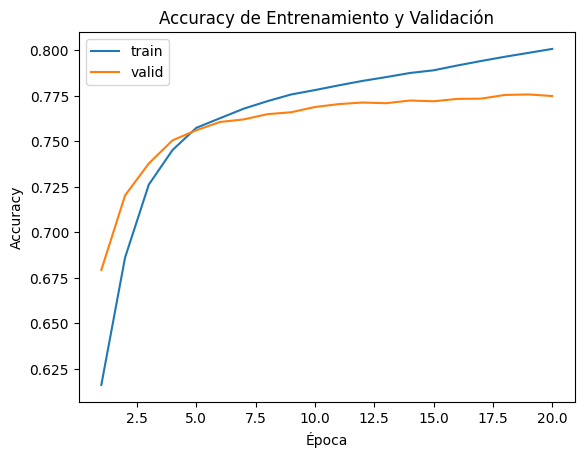

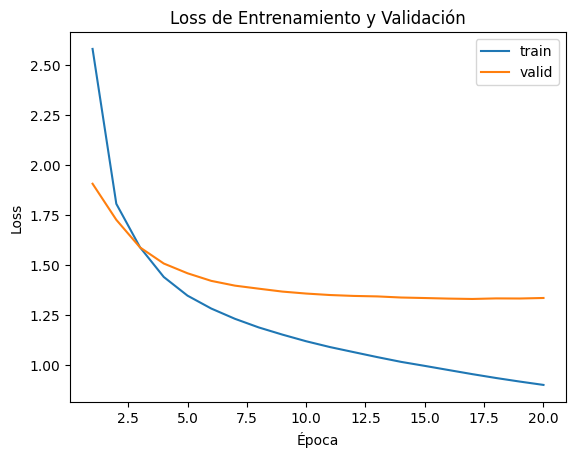

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

epoch_count = range(1, len(hist.history['accuracy']) + 1)

# Accuracy
sns.lineplot(x=epoch_count, y=hist.history['accuracy'], label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title('Accuracy de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.show()

# Loss
sns.lineplot(x=epoch_count, y=hist.history['loss'], label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_loss'], label='valid')
plt.title('Loss de Entrenamiento y Validación')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.show()

## Conclusiones:

El modelo aprende bien al principio, con un salto significativo de accuracy en las primeras épocas. La validación continúa mejorando lentamente hasta ~época 10, momento en el que la val_loss se estanca  mientras el train_loss sigue bajando, evidenciando lo que podria ser un overfitting.


# 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

In [ ]:
# Crear los modelos encoder y decoder para inferencia

# Encoder model para inferencia
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder model para inferencia
# States inputs
decoder_state_input_h = Input(shape=(n_units,))
decoder_state_input_c = Input(shape=(n_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Decoder inputs
decoder_inputs_single = Input(shape=(1,))
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)

# Decoder LSTM
decoder_outputs_single, state_h_single, state_c_single = decoder_lstm(
    decoder_inputs_single_x,
    initial_state=decoder_states_inputs
)

# Decoder Dense
decoder_outputs_single = Dropout(0.2)(decoder_outputs_single)
decoder_outputs_single = decoder_dense(decoder_outputs_single)
decoder_states_outputs = [state_h_single, state_c_single]

# Decoder model
decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs,
    [decoder_outputs_single] + decoder_states_outputs
)

# Mapeo de índices a palabras de salida
idx2word_target = {v: k for k, v in output_tokenizer.word_index.items()}

# Función para responder una pregunta
def answer_question(input_seq):
    # Se transforman la secuencia de entrada a los estados "h" y "c" de la LSTM
    # para enviar la primera vez al decoder
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Se inicializa la secuencia de entrada al decoder como "<sos>"
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = output_tokenizer.word_index.get('<sos>', 1)

    # Se obtiene el índice que finaliza la inferencia
    eos = output_tokenizer.word_index.get('<eos>', 2)

    output_sentence = []
    for _ in range(max_out_len):
        # Predicción del próximo elemento
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])

        # Si es "end of sentence <eos>" se acaba
        if eos == idx:
            break

        # Transformar idx a palabra
        if idx > 0:
            word = idx2word_target.get(idx, '<unk>')
            if word not in ['<sos>', '<eos>', '<unk>']:
                output_sentence.append(word)

        # Actualizar los estados dada la última predicción
        states_value = [h, c]

        # Actualizar secuencia de entrada con la salida (re-alimentación)
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

# Array de preguntas para probar el chatbot
questions = [
    "hi",
    "how are you today",
    "what is your name",
    "do you like coding",
    "hello how are you",
    "what is your favorite food",
    "what do you do for work",
    "tell me a joke"
]

print("=== QA CHATBOT - RESPUESTAS CON DETALLES ===\n")
for question in questions:
    print("-" * 80)
    # Tokenizar la pregunta
    integer_seq = input_tokenizer.texts_to_sequences([question])[0]
    print(f"Input: {question}")
    print(f"Representacion en vector de tokens de ids: {integer_seq}")
    
    # Padding
    input_seq = pad_sequences([integer_seq], maxlen=max_input_len)
    print(f"Padding del vector: {input_seq}")
    
    print(f"Input: {question}")
    
    # Obtener respuesta del chatbot
    answer = answer_question(input_seq)
    print(f"Response: {answer}")
    print()

=== QA CHATBOT - RESPUESTAS CON DETALLES ===

--------------------------------------------------------------------------------
Input: hi
Representacion en vector de tokens de ids: [17]
Padding del vector: [[ 0  0  0  0  0  0  0  0  0  0  0  0  0 17]]
Input: hi
Response: hi how are you

--------------------------------------------------------------------------------
Input: how are you today
Representacion en vector de tokens de ids: [12, 9, 2, 56]
Padding del vector: [[ 0  0  0  0  0  0  0  0  0  0 12  9  2 56]]
Input: how are you today
Response: i am doing well how are you

--------------------------------------------------------------------------------
Input: what is your name
Representacion en vector de tokens de ids: [4, 8, 21, 44]
Padding del vector: [[ 0  0  0  0  0  0  0  0  0  0  4  8 21 44]]
Input: what is your name
Response: i like to go to the beach

--------------------------------------------------------------------------------
Input: do you like coding
Representacion en ve

# Conclusión

Segun los resultados de accuracy alcanzados en el entrenamiento, el modelo deberia responder bien. Sin embargo, al realizar algunas pruebas vemos que no siempre responde con coherencia. Semanticamente las respuestas generadas son siempre correctas, el modelo esta fallando al responder con sentido el input recibido.

Como oportunidades de mejora vemos que podriamos:
- Consumir un dataset mas grande
- No cortar el vocabulario maximo o la longitud de las sentencias
- Utilizar un transformer